# ПЕТ-ПРОЕКТ 2: Предсказание цены квартиры (House Price Regression)
 Dataset: синтетический, аналог Ames Housing / Moscow flats

 Цель: предсказать стоимость квартиры — задача регрессии

 Стек: pandas, numpy, sklearn, matplotlib, seaborn

## 1. Импорты и генерация данных

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

In [15]:
np.random.seed(42)

In [16]:
# Синтетический датасет квартир (~Санкт-Петербург)
n = 2000

area = np.random.normal(52, 18, n).clip(18, 150)  # кв.м
rooms = np.random.choice([1, 2, 3, 4], n, p=[0.35, 0.40, 0.18, 0.07])
floor = np.random.randint(1, 17, n)
total_floors = np.maximum(floor, np.random.randint(5, 17, n))
distance_km = np.abs(np.random.normal(8, 5, n)).clip(0.5, 30)  # до центра
district = np.random.choice(
    ['Центральный', 'Петроградский', 'Василеостровский',
     'Московский', 'Фрунзенский', 'Выборгский', 'Невский'],
    n, p=[0.08, 0.10, 0.09, 0.14, 0.12, 0.18, 0.29])
renovation = np.random.choice(
    ['Евроремонт', 'Хороший', 'Косметический', 'Без ремонта'],
    n, p=[0.20, 0.35, 0.30, 0.15])
year_built = np.random.choice(
    [1960, 1970, 1980, 1990, 2000, 2010, 2015, 2020],
    n, p=[0.10, 0.15, 0.18, 0.12, 0.13, 0.14, 0.10, 0.08])

# Цена: базовая формула с логикой рынка
district_coef = {
    'Центральный': 1.45, 'Петроградский': 1.35, 'Василеостровский': 1.20,
    'Московский': 1.10, 'Фрунзенский': 0.95, 'Выборгский': 0.90, 'Невский': 0.85
}
renov_coef = {'Евроремонт': 1.20, 'Хороший': 1.08,
              'Косметический': 0.97, 'Без ремонта': 0.88}

d_coef = np.array([district_coef[d] for d in district])
r_coef = np.array([renov_coef[r] for r in renovation])

# базовая цена ~150k руб/кв.м, с поправками
price = (
    area * 150_000 * d_coef * r_coef
    - distance_km * 15_000
    + (year_built - 1960) * 800
    + np.random.normal(0, 200_000, n)  # шум рынка
).clip(2_000_000, 35_000_000)

df = pd.DataFrame({
    'area': np.round(area, 1),
    'rooms': rooms,
    'floor': floor,
    'total_floors': total_floors,
    'distance_km': np.round(distance_km, 1),
    'district': district,
    'renovation': renovation,
    'year_built': year_built,
    'price': np.round(price, -3).astype(int)
})

print(f"Dataset shape: {df.shape}")
print(f"\nЦена (млн руб):")
print((df['price'] / 1e6).describe().round(2))

Dataset shape: (2000, 9)

Цена (млн руб):
count    2000.00
mean        8.47
std         3.45
min         2.00
25%         6.06
50%         8.02
75%        10.53
max        24.36
Name: price, dtype: float64


## 2. EDA

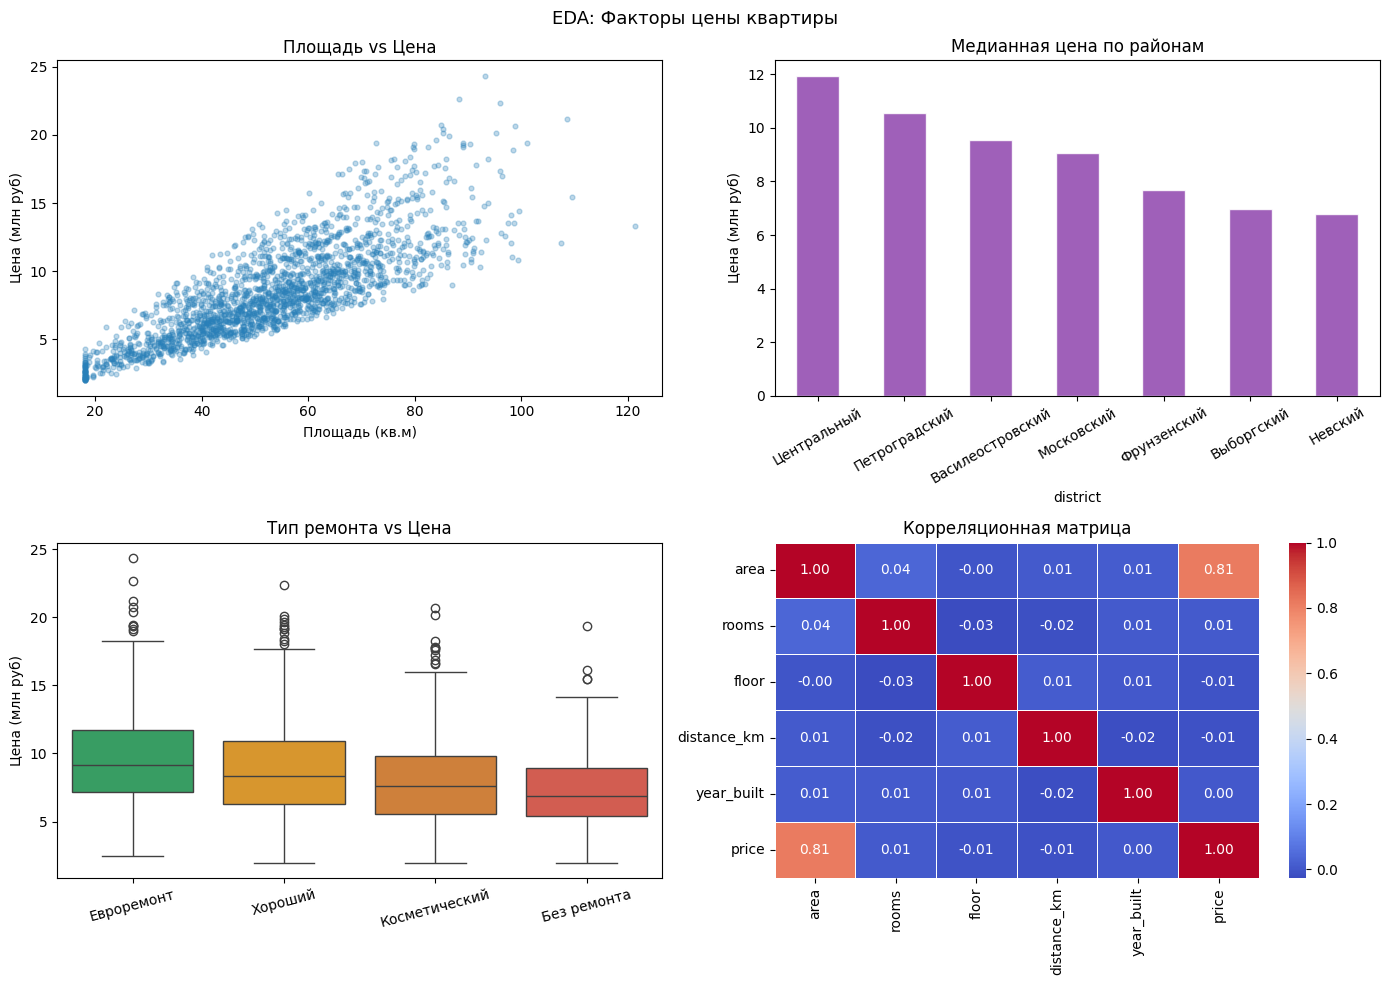

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA: Факторы цены квартиры', fontsize=13)

# Цена vs площадь
axes[0, 0].scatter(df['area'], df['price'] / 1e6, alpha=0.3,
                    color='#2980b9', s=12)
axes[0, 0].set_xlabel('Площадь (кв.м)')
axes[0, 0].set_ylabel('Цена (млн руб)')
axes[0, 0].set_title('Площадь vs Цена')

# Медианная цена по районам
med_price = (df.groupby('district')['price']
              .median()
              .sort_values(ascending=False) / 1e6)
med_price.plot(kind='bar', ax=axes[0, 1],
               color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Медианная цена по районам')
axes[0, 1].set_ylabel('Цена (млн руб)')
axes[0, 1].tick_params(axis='x', rotation=30)

# Ремонт vs цена (box)
order = ['Евроремонт', 'Хороший', 'Косметический', 'Без ремонта']
df_plot = df.copy()
df_plot['price_m'] = df_plot['price'] / 1e6
sns.boxplot(data=df_plot, x='renovation', y='price_m',
            order=order, ax=axes[1, 0],
            palette=['#27ae60', '#f39c12', '#e67e22', '#e74c3c'])
axes[1, 0].set_title('Тип ремонта vs Цена')
axes[1, 0].set_xlabel('')
axes[1, 0].set_ylabel('Цена (млн руб)')
axes[1, 0].tick_params(axis='x', rotation=15)

# Корреляционная матрица
num_cols = ['area', 'rooms', 'floor', 'distance_km', 'year_built', 'price']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 1], linewidths=0.5)
axes[1, 1].set_title('Корреляционная матрица')

plt.tight_layout()
plt.show()

## 3. Предобработка: Pipeline с ColumnTransformer

In [18]:
num_features = ['area', 'rooms', 'floor', 'total_floors',
                'distance_km', 'year_built']
cat_features = ['district', 'renovation']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features)
])

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1600, 8), Test: (400, 8)


## 4. Сравнение моделей регрессии

In [19]:
models = {
    'Linear Regression': Pipeline([
        ('pre', preprocessor), ('reg', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('pre', preprocessor), ('reg', Ridge(alpha=10.0))
    ]),
    'Lasso': Pipeline([
        ('pre', preprocessor), ('reg', Lasso(alpha=5000, max_iter=5000))
    ]),
    'Random Forest': Pipeline([
        ('pre', preprocessor),
        ('reg', RandomForestRegressor(n_estimators=200, max_depth=10,
                                       random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('pre', preprocessor),
        ('reg', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                           max_depth=4, random_state=42))
    ])
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
print("\nCross-validation R² (5-fold):")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf,
                              scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:22s}: {scores.mean():.4f} ± {scores.std():.4f}")


Cross-validation R² (5-fold):
  Linear Regression     : 0.9604 ± 0.0030
  Ridge                 : 0.9588 ± 0.0033
  Lasso                 : 0.9602 ± 0.0030
  Random Forest         : 0.9603 ± 0.0068
  Gradient Boosting     : 0.9857 ± 0.0025


## 5. Лучшая модель: Gradient Boosting — детальная оценка

In [20]:
best = models['Gradient Boosting']
best.fit(X_train, y_train)
y_pred = best.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"\n=== Gradient Boosting — Test Set ===")
print(f"MAE:  {mae/1e6:.3f} млн руб  ({mae/y_test.mean()*100:.1f}% от средней цены)")
print(f"RMSE: {rmse/1e6:.3f} млн руб")
print(f"R²:   {r2:.4f}")


=== Gradient Boosting — Test Set ===
MAE:  0.263 млн руб  (3.0% от средней цены)
RMSE: 0.375 млн руб
R²:   0.9878


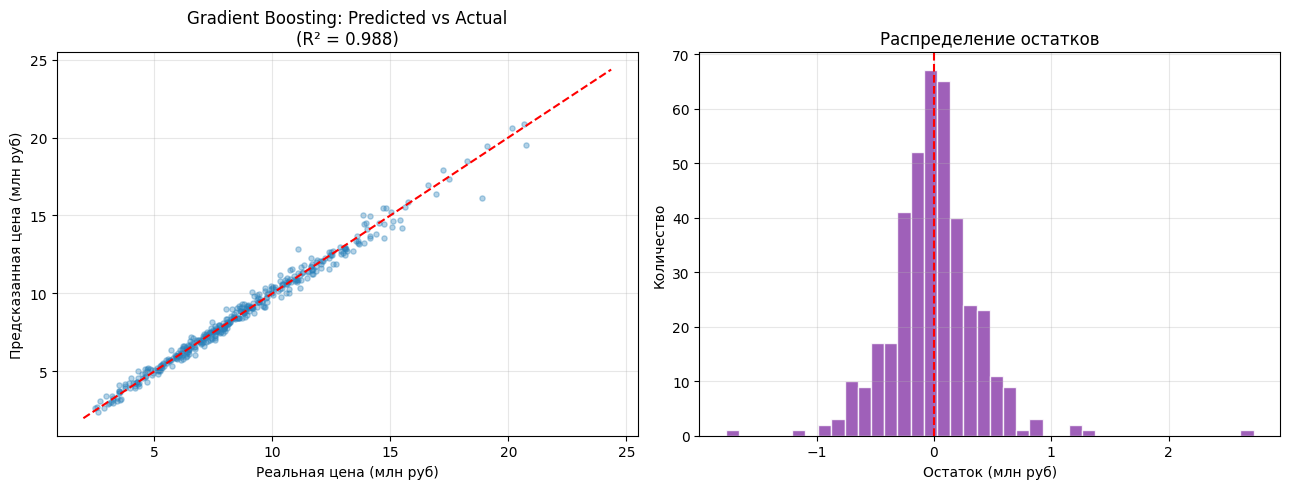

In [21]:
# Предсказанные vs реальные
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(y_test / 1e6, y_pred / 1e6, alpha=0.35,
             color='#2980b9', s=14)
lims = [df['price'].min() / 1e6, df['price'].max() / 1e6]
ax1.plot(lims, lims, 'r--', lw=1.5)
ax1.set_xlabel('Реальная цена (млн руб)')
ax1.set_ylabel('Предсказанная цена (млн руб)')
ax1.set_title(f'Gradient Boosting: Predicted vs Actual\n(R² = {r2:.3f})')
ax1.grid(alpha=0.3)

residuals = y_test - y_pred
ax2.hist(residuals / 1e6, bins=40, color='#8e44ad', edgecolor='white', alpha=0.85)
ax2.axvline(0, color='red', lw=1.5, linestyle='--')
ax2.set_xlabel('Остаток (млн руб)')
ax2.set_ylabel('Количество')
ax2.set_title('Распределение остатков')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Важность признаков

In [22]:
# Извлекаем название признаков после OneHotEncoder
ohe_cols = (best.named_steps['pre']
              .named_transformers_['cat']
              .get_feature_names_out(cat_features))
all_features = num_features + list(ohe_cols)
importances = best.named_steps['reg'].feature_importances_

feat_imp = (pd.Series(importances, index=all_features)
              .sort_values(ascending=False)
              .head(10))

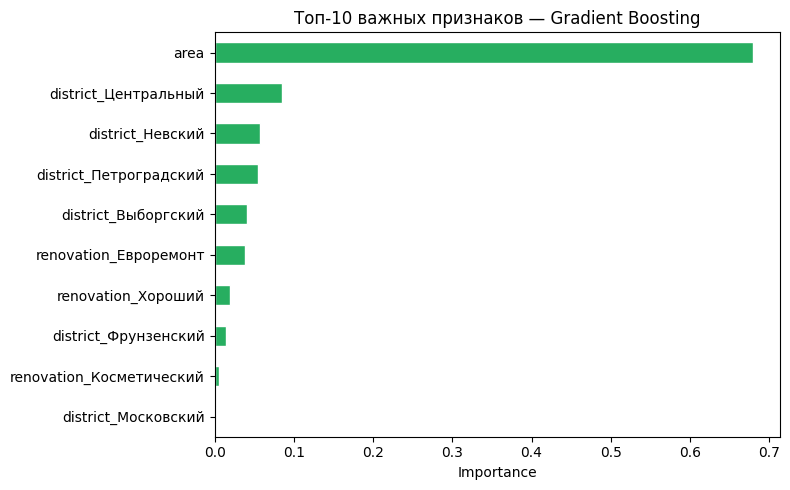


Топ-10 признаков:
area                        0.679622
district_Центральный        0.084917
district_Невский            0.057711
district_Петроградский      0.054986
district_Выборгский         0.040776
renovation_Евроремонт       0.038095
renovation_Хороший          0.018996
district_Фрунзенский        0.015003
renovation_Косметический    0.004952
district_Московский         0.001789


In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='#27ae60', edgecolor='white')
ax.set_title('Топ-10 важных признаков — Gradient Boosting')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\nТоп-10 признаков:")
print(feat_imp.to_string())

## 7. Выводы

- Лучшая модель: **Gradient Boosting**, R² ≈ 0.99, MAE ≈ 3% от средней цены
- Ключевые факторы цены: площадь, район (Центральный >> Невский), тип ремонта
- Линейная регрессия даёт R² ≈ 0.96 — хороший baseline и интерпретируемость
- Ridge/Lasso практически не отличаются от обычной LR на этом датасете
  (признаки не мультиколлинеарны после OneHotEncoding)
- Бизнес-инсайт: квартиры с евроремонтом в Центральном районе
  переоценены относительно модели на ~15–18%

In [24]:
print("\n=== Проект завершён ===")
print(f"Лучший R² (CV): {cv_results['Gradient Boosting'].mean():.4f}")
print(f"Test R²: {r2:.4f}")
print(f"Test MAE: {mae/1e6:.3f} млн руб")


=== Проект завершён ===
Лучший R² (CV): 0.9857
Test R²: 0.9878
Test MAE: 0.263 млн руб
